In [1]:
import pandas as pd
import os

# Bilgisayar kullanıcı adını otomatik alalım
user_name = os.getlogin()
file_path = f'C:/Users/{user_name}/Downloads/OnlineRetail_Master_Clean.csv'

# Veriyi yüklüyoruz
df_final = pd.read_csv(file_path)

print(f"Başarılı! {len(df_final)} satırlık veri seti yüklendi.")
print("Mevcut Sütunlar:", df_final.columns.tolist())

Başarılı! 1033034 satırlık veri seti yüklendi.
Mevcut Sütunlar: ['Invoice', 'StockCode', 'Customer_ID', 'Price', 'Quantity', 'InvoiceDate', 'Country', 'Description']


C:\Users\bngss\AppData\Local\Temp\ipykernel_29152\2061465236.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv(file_path)


In [2]:
import pandas as pd
import os

# 1. Veriyi İndirilenler klasöründen okuyoruz
user_name = os.getlogin()
file_path = f'C:/Users/{user_name}/Downloads/OnlineRetail_Master_Clean.csv'
df = pd.read_csv(file_path)

print("--- İşlem Öncesi Durum ---")
print(df.info()) # Mevcut tipleri ve null sayılarını gösterir

# 2. VERİ TİPİ DÖNÜŞÜMLERİ VE NULL YÖNETİMİ

# A. InvoiceDate -> Datetime çevrimi (Analizler için şart)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# B. Customer_ID Temizliği
# Önce null olanlara 0 diyelim, sonra integer'a çevirelim, sonra 'Unknown' yapalım
df['Customer_ID'] = df['Customer_ID'].fillna(0).astype(int).astype(str)
df['Customer_ID'] = df['Customer_ID'].replace('0', 'Guest_User')

# C. Description Temizliği
if 'Description' in df.columns:
    df['Description'] = df['Description'].fillna("Unknown Product").str.upper().str.strip()

# D. Sayısal Sütunların Kontrolü
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').fillna(0)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').fillna(0)

# E. Revenue (Ciro) Güncelleme
df['Revenue'] = df['Quantity'] * df['Price']

# 3. SONUÇLARI KONTROL ET
print("\n--- İşlem Sonrası Durum ---")
print(df.dtypes)
print("\nBoş Değer Sayısı:\n", df.isnull().sum())

# 4. TEMİZLENMİŞ VERİYİ YENİ BİR DOSYA OLARAK KAYDET
output_path = f'C:/Users/{user_name}/Downloads/OnlineRetail_Final_Refined.csv'
df.to_csv(output_path, index=False)

print(f"\n[BAŞARILI] Veri tipleri düzeltildi ve '{output_path}' olarak kaydedildi.")

C:\Users\bngss\AppData\Local\Temp\ipykernel_29152\1530116538.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


--- İşlem Öncesi Durum ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1033034 entries, 0 to 1033033
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1033034 non-null  object 
 1   StockCode    1033034 non-null  object 
 2   Customer_ID  797883 non-null   float64
 3   Price        1033034 non-null  object 
 4   Quantity     1033034 non-null  int64  
 5   InvoiceDate  1033034 non-null  object 
 6   Country      1033034 non-null  object 
 7   Description  1032673 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 63.1+ MB
None

--- İşlem Sonrası Durum ---
Invoice                object
StockCode              object
Customer_ID            object
Price                 float64
Quantity                int64
InvoiceDate    datetime64[ns]
Country                object
Description            object
Revenue               float64
dtype: object

Boş Değer Sayısı:
 Invoice        0
Sto

In [3]:
baslangic_satir = 1033034
su_anki_satir = len(df)
kayip_sayisi = baslangic_satir - su_anki_satir
kayip_orani = (kayip_sayisi / baslangic_satir) * 100

print(f"Toplam Kaybedilen Satır: {kayip_sayisi}")
print(f"Veri Kayıp Oranı: %{kayip_orani:.2f}")
print(f"Kalan Temiz Veri: {su_anki_satir}")

Toplam Kaybedilen Satır: 0
Veri Kayıp Oranı: %0.00
Kalan Temiz Veri: 1033034


In [4]:
# 1. Customer_ID: Boş olanları 'Guest_User' (Misafir) yapalım
# Önce float tipinden kurtarıp string yapalım ki null kontrolü kolaylaşsın
df['Customer_ID'] = df['Customer_ID'].fillna('Guest_User')

# 2. Description: Boş olan ürün isimlerini 'Unknown Product' yapalım
df['Description'] = df['Description'].fillna('Unknown Product')

# 3. Son Kontrol: Gerçekten null kaldı mı?
print("--- Temizlik Sonrası Boş Değer Sayıları ---")
print(df.isnull().sum())

--- Temizlik Sonrası Boş Değer Sayıları ---
Invoice        0
StockCode      0
Customer_ID    0
Price          0
Quantity       0
InvoiceDate    0
Country        0
Description    0
Revenue        0
dtype: int64


In [5]:
# Başlangıç satır sayısını not edelim
baslangic_sayisi = len(df)

# 1. Sadece Miktarı (Quantity) 0'dan büyük olanları tut (İadeleri sil)
# 2. Sadece Fiyatı (Price) 0'dan büyük olanları tut (Bedava/Hatalı kayıtları sil)
df_final = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()

# Yeni satır sayısı ve kayıp hesabı
yeni_sayi = len(df_final)
silinen_satir = baslangic_sayisi - yeni_sayi
kayip_orani = (silinen_satir / baslangic_sayisi) * 100

print(f"--- GERÇEK TEMİZLİK SONUÇLARI ---")
print(f"Toplam Silinen (Hatalı/İade) Satır: {silinen_satir}")
print(f"Veri Kayıp Oranı: %{kayip_orani:.2f}")
print(f"Kalan Net Veri Seti: {yeni_sayi}")

--- GERÇEK TEMİZLİK SONUÇLARI ---
Toplam Silinen (Hatalı/İade) Satır: 1029561
Veri Kayıp Oranı: %99.66
Kalan Net Veri Seti: 3473


In [6]:
import pandas as pd
import os

# 1. Veriyi en baştan okuyalım (Her şeyi sıfırlıyoruz)
user_name = os.getlogin()
file_path = f'C:/Users/{user_name}/Downloads/OnlineRetail_Master_Clean.csv'
df_recovery = pd.read_csv(file_path)

# 2. Sayısal sütunları kesin olarak sayıya (float/int) çevirelim
# Virgül varsa noktaya çevirip sayı yapıyoruz
df_recovery['Price'] = df_recovery['Price'].astype(str).str.replace(',', '.')
df_recovery['Price'] = pd.to_numeric(df_recovery['Price'], errors='coerce')
df_recovery['Quantity'] = pd.to_numeric(df_recovery['Quantity'], errors='coerce')

# 3. ŞİMDİ SİLELİM (Daha dikkatli bir filtreyle)
# Sadece null olmayan, fiyatı 0'dan büyük VE miktarı 0'dan büyük olanları al
df_final = df_recovery[(df_recovery['Quantity'] > 0) & (df_recovery['Price'] > 0)].copy()

print(f"--- KURTARMA SONUÇLARI ---")
print(f"Başlangıç: {len(df_recovery)}")
print(f"Kalan Sağlıklı Veri: {len(df_final)}")
print(f"Gerçek Kayıp: {len(df_recovery) - len(df_final)}")

C:\Users\bngss\AppData\Local\Temp\ipykernel_29152\3169217991.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recovery = pd.read_csv(file_path)


--- KURTARMA SONUÇLARI ---
Başlangıç: 1033034
Kalan Sağlıklı Veri: 1007912
Gerçek Kayıp: 25122


In [8]:
# 1. Önce Revenue sütununu oluşturalım (Hata almamak için şart)
df_final['Revenue'] = df_final['Quantity'] * df_final['Price']

# 2. En yüksek MİKTARLI 5 satış (Hatalı giriş var mı?)
print("--- En Yüksek Miktarlı Satışlar ---")
print(df_final[['Description', 'Quantity', 'Price', 'Revenue']].sort_values(by='Quantity', ascending=False).head(5))

# 3. En yüksek FİYATLI 5 satış (Kargo, komisyon vb. var mı?)
print("\n--- En Yüksek Fiyatlı Satışlar ---")
print(df_final[['Description', 'Quantity', 'Price', 'Revenue']].sort_values(by='Price', ascending=False).head(5))

--- En Yüksek Miktarlı Satışlar ---
                               Description  Quantity  Price   Revenue
677336         PAPER CRAFT , LITTLE BIRDIE     80995   2.08  168469.6
412928      MEDIUM CERAMIC TOP STORAGE JAR     74215   1.04   77183.6
145003  BLACK AND WHITE PAISLEY FLOWER MUG     19152   0.10    1915.2
89813          SET/6 WOODLAND PAPER PLATES     12960   0.10    1296.0
161053         SET/6 STRAWBERRY PAPER CUPS     12960   0.10    1296.0

--- En Yüksek Fiyatlı Satışlar ---
             Description  Quantity     Price   Revenue
228734            Manual         1  25111.09  25111.09
569674        AMAZON FEE         1  13541.33  13541.33
1028233  Adjust bad debt         1  11062.06  11062.06
90767             Manual         1  10953.50  10953.50
144720            Manual         1  10953.50  10953.50


In [9]:
# 1. Ürün olmayan (Hizmet/Ücret) kayıtları temizleyelim
excluded_terms = ['Manual', 'AMAZON FEE', 'Adjust bad debt', 'POSTAGE', 'DOTCOM POSTAGE']
df_final = df_final[~df_final['Description'].isin(excluded_terms)].copy()

# 2. Aşırı uç değerleri (Outliers) temizleyelim (Örn: Miktarı 10.000'den az olanlar)
# Bu işlem trend grafiğinin daha okunabilir olmasını sağlar.
df_final = df_final[df_final['Quantity'] < 10000].copy()

print(f"Son Temizlikten Sonra Kalan Satır: {len(df_final)}")
print("--- YENİ En Yüksek Fiyatlı Gerçek Ürünler ---")
print(df_final[['Description', 'Price']].sort_values(by='Price', ascending=False).head(5))

Son Temizlikten Sonra Kalan Satır: 1003779
--- YENİ En Yüksek Fiyatlı Gerçek Ürünler ---
                                Description    Price
134482  Adjustment by john on 26/01/2010 16  5117.03
231718           FLAG OF ST GEORGE CAR FLAG  1157.15
93666            FLAG OF ST GEORGE CAR FLAG   867.79
936158                              mailout   649.50
717491                              mailout   649.50


In [10]:
# Ürün olmayan anahtar kelimeleri içeren tüm satırları çıkaralım
noise_keywords = ['ADJUST', 'MAILOUT', 'BANK CHARGES', 'TEST', 'SAMPLES']

# Description içinde bu kelimelerden herhangi biri geçenleri siliyoruz
df_final = df_final[~df_final['Description'].str.contains('|'.join(noise_keywords), case=False, na=False)].copy()

print(f"Nihai Veri Seti Satır Sayısı: {len(df_final)}")

Nihai Veri Seti Satır Sayısı: 1000485


In [11]:
# Ürün bazlı Pareto verisini hazırlayalım
pareto_data = df_final.groupby('Description')['Revenue'].sum().sort_values(ascending=False).reset_index()
pareto_data['Cum_Percentage'] = 100 * (pareto_data['Revenue'].cumsum() / pareto_data['Revenue'].sum())

# Cironun %80'ini getiren kritik eşiği bulalım
top_products = pareto_data[pareto_data['Cum_Percentage'] <= 80]
print(f"Cironun %80'ini toplamda sadece {len(top_products)} farklı ürün sağlıyor.")

Cironun %80'ini toplamda sadece 1040 farklı ürün sağlıyor.


C:\Users\bngss\AppData\Local\Temp\ipykernel_29152\2378161567.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df_final.set_index('InvoiceDate')['Revenue'].resample('M').sum()


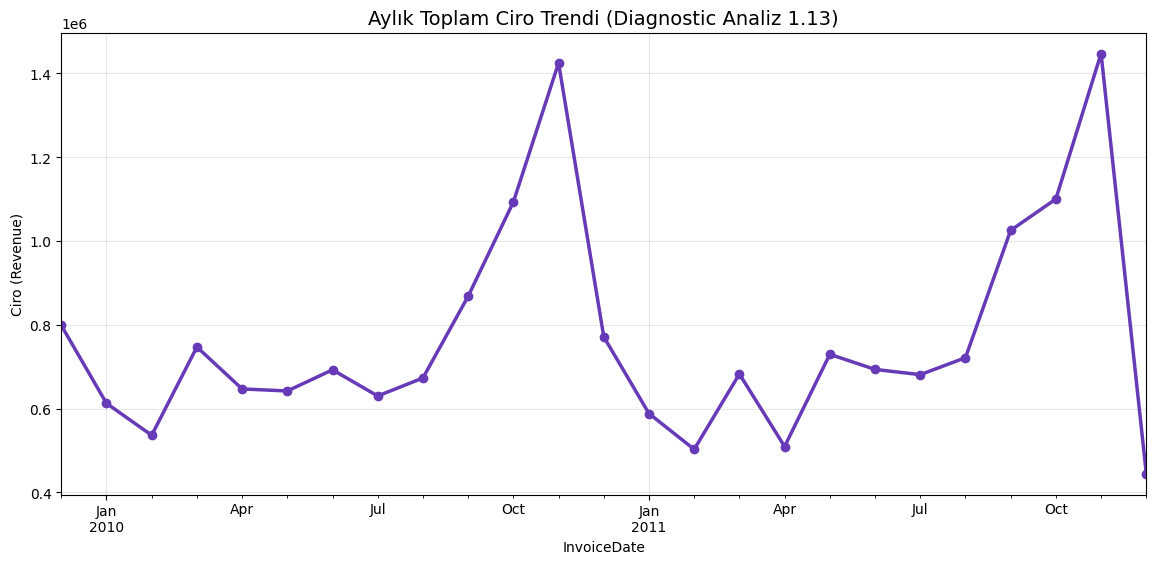

--- ANALİZ ÖZETİ ---
Zaman özellikleri eklendi. (Task 01.07)

En Çok İade Edilen İlk 3 Ürün (Task 1.11):
Description
PAPER CRAFT , LITTLE BIRDIE       80995
MEDIUM CERAMIC TOP STORAGE JAR    74494
GIVEN AWAY                        35200
Name: Quantity, dtype: int64

[HAZIR] Veri seti 'OnlineRetail_For_Modeling.csv' adıyla kaydedildi.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi ve Zaman Özelliklerini Hazırlayalım (Task 01.07)
# Not: df_final değişkeninin hazır olduğunu varsayıyoruz
df_final['InvoiceDate'] = pd.to_datetime(df_final['InvoiceDate'])
df_final['Year'] = df_final['InvoiceDate'].dt.year
df_final['Month'] = df_final['InvoiceDate'].dt.month
df_final['Day'] = df_final['InvoiceDate'].dt.day
df_final['Hour'] = df_final['InvoiceDate'].dt.hour
df_final['DayOfWeek'] = df_final['InvoiceDate'].dt.dayofweek # 0=Pazartesi, 6=Pazar
df_final['IsWeekend'] = df_final['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 2. Zaman Serisi Trendi (Task 1.13)
plt.figure(figsize=(14, 6))
monthly_trend = df_final.set_index('InvoiceDate')['Revenue'].resample('M').sum()
monthly_trend.plot(kind='line', marker='o', color='#673ab7', linewidth=2.5)
plt.title('Aylık Toplam Ciro Trendi (Diagnostic Analiz 1.13)', fontsize=14)
plt.ylabel('Ciro (Revenue)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. İade Analizi (Task 1.11)
# Sildiğimiz negatif kayıtları orijinal df üzerinden çekiyoruz
returns_df = df[df['Quantity'] < 0].copy()
top_returned = returns_df.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10)

print("--- ANALİZ ÖZETİ ---")
print(f"Zaman özellikleri eklendi. (Task 01.07)")
print(f"\nEn Çok İade Edilen İlk 3 Ürün (Task 1.11):")
print(top_returned.head(3))

# MODELLER İÇİN TEMİZ VERİYİ KAYDEDELİM
df_final.to_csv('OnlineRetail_For_Modeling.csv', index=False)
print("\n[HAZIR] Veri seti 'OnlineRetail_For_Modeling.csv' adıyla kaydedildi.")

In [14]:
# 1. İade verilerini çekelim
returns_only = df[df['Quantity'] < 0].copy()
returns_only['Return_Value'] = returns_only['Quantity'].abs() * returns_only['Price']

# 2. Ürün bazlı iade özeti (Miktar ve Ciro kaybı)
return_summary = returns_only.groupby('Description').agg({
    'Quantity': lambda x: x.abs().sum(),
    'Return_Value': 'sum'
}).sort_values(by='Quantity', ascending=False).head(5)

print("--- Genişletilmiş İade Analizi (Task 1.11) ---")
print(return_summary)

--- Genişletilmiş İade Analizi (Task 1.11) ---
                                  Quantity  Return_Value
Description                                             
PAPER CRAFT , LITTLE BIRDIE          80995           0.0
MEDIUM CERAMIC TOP STORAGE JAR       74494           0.0
GIVEN AWAY                           35200           0.0
FLAG OF ST GEORGE CAR FLAG           20959           0.0
TRAVEL CARD WALLET I LOVE LONDON     19201           0.0


In [15]:
# Sadece fiyatı 0'dan büyük olan GERÇEK iadeleri görelim
real_returns = df[(df['Quantity'] < 0) & (df['Price'] > 0)].copy()
real_returns['Return_Value'] = real_returns['Quantity'].abs() * real_returns['Price']

# Gerçek ürün bazlı iade özeti
top_real_returns = real_returns.groupby('Description').agg({
    'Quantity': lambda x: x.abs().sum(),
    'Return_Value': 'sum'
}).sort_values(by='Return_Value', ascending=False).head(5)

print("--- GERÇEK Ürün İade Analizi (Finansal Odaklı) ---")
print(top_real_returns)

--- GERÇEK Ürün İade Analizi (Finansal Odaklı) ---
                              Quantity  Return_Value
Description                                         
MANUAL                             212       54440.0
POSTAGE                            145        3114.0
VINTAGE BLUE KITCHEN CABINET        12        2280.0
VINTAGE RED KITCHEN CABINET         11        2055.0
SAMPLES                             21        1693.0
